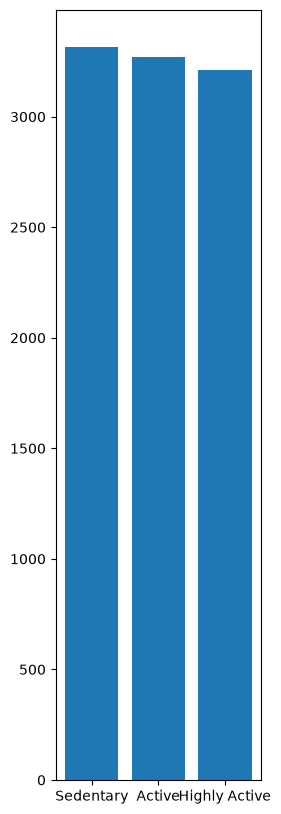

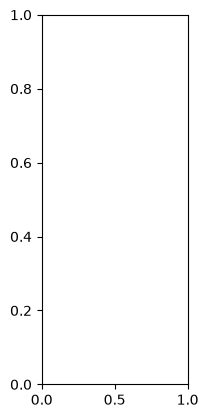

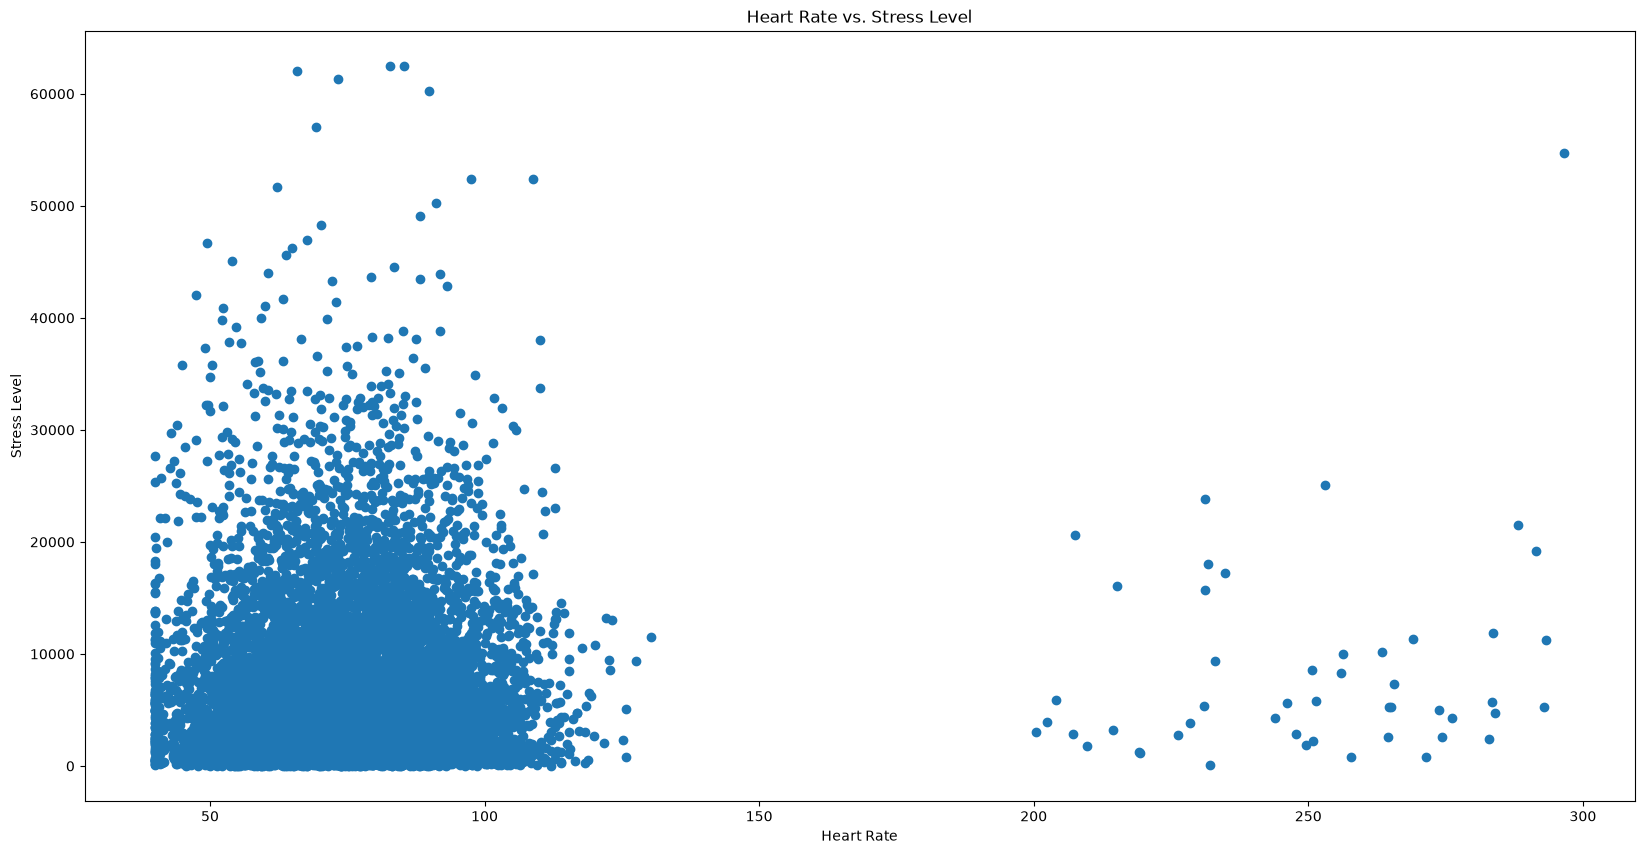

In [29]:
# Loaded variable 'df' from URI: c:\Users\barra\Documents\VS CODE\unclean_smartwatch_health_data.csv
import pandas as pd
import random
import numpy as np 
import impyute 
import os
import matplotlib.pyplot as plt

df = pd.read_csv(r'c:\Users\barra\Documents\VS CODE\unclean_smartwatch_health_data.csv')

df['Activity Level'] = df['Activity Level'].replace('Seddentary', 'Sedentary')
df['Stress Level'] = df['Stress Level'].replace('Very High', '9')
df['Stress Level'] = pd.to_numeric(df['Stress Level'])
df['Activity Level'] = df['Activity Level'].replace('Highly_Active', 'Highly Active')
df=df.dropna(subset=['User ID'])
df = df.ffill(axis = 0, inplace = True )

sleep_mean = pd.to_numeric(df['Sleep Duration (hours)'], errors='coerce').mean()
df['Sleep Duration (hours)'] = df['Sleep Duration (hours)'].replace('ERROR', sleep_mean)

df['Sleep Duration (hours)'] = pd.to_numeric(df['Sleep Duration (hours)'])
df = df.round(2)
df['Step Count'] = df['Step Count'].round(0)

df['Activity Level'] = df['Activity Level'].replace('Actve', 'Active')
# os.getcwd()
df.dtypes

df.to_csv('cleaned smartwatch data.csv', index = False)
avg_heart_rate = df.groupby("Activity Level")["Heart Rate (BPM)"].mean()
x_values = df['Activity Level'].value_counts()
y_values = range(1,10000)
plt.figure(figsize = (9,10))
ax=plt.subplot(1,3,1)
plt.bar(x_values.index, x_values.values)
plt.show()
ax2=plt.subplot(1,3,2)
plt.figure(figsize= (20, 10))
plt.scatter(df["Heart Rate (BPM)"], df["Step Count"])
plt.xlabel("Heart Rate")
plt.ylabel("Stress Level")
plt.title("Heart Rate vs. Stress Level")
plt.show()
